In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
os.makedirs("charts", exist_ok=True)

In [3]:
restaurants = pd.read_csv("/Users/aakashreddy/Desktop/fast-food-restaurant-analysis/data/raw/fast_food_restaurants.csv")
state_pop = pd.read_csv("/Users/aakashreddy/Desktop/fast-food-restaurant-analysis/data/raw/state_population.csv")

In [4]:
state_map = {
    'AL':'Alabama','AK':'Alaska','AZ':'Arizona','AR':'Arkansas',
    'CA':'California','CO':'Colorado','CT':'Connecticut','DE':'Delaware',
    'DC':'District of Columbia',
    'FL':'Florida','GA':'Georgia','HI':'Hawaii','ID':'Idaho',
    'IL':'Illinois','IN':'Indiana','IA':'Iowa','KS':'Kansas',
    'KY':'Kentucky','LA':'Louisiana','ME':'Maine','MD':'Maryland',
    'MA':'Massachusetts','MI':'Michigan','MN':'Minnesota',
    'MS':'Mississippi','MO':'Missouri','MT':'Montana',
    'NE':'Nebraska','NV':'Nevada','NH':'New Hampshire',
    'NJ':'New Jersey','NM':'New Mexico','NY':'New York',
    'NC':'North Carolina','ND':'North Dakota','OH':'Ohio',
    'OK':'Oklahoma','OR':'Oregon','PA':'Pennsylvania',
    'RI':'Rhode Island','SC':'South Carolina','SD':'South Dakota',
    'TN':'Tennessee','TX':'Texas','UT':'Utah','VT':'Vermont',
    'VA':'Virginia','WA':'Washington','WV':'West Virginia',
    'WI':'Wisconsin','WY':'Wyoming'
}

In [5]:
state_counts = (
    restaurants.groupby("province")
    .size()
    .reset_index(name="restaurant_count")
)

state_counts["state_name"] = (
    state_counts["province"]
    .map(state_map)
)

state_counts = state_counts[
    state_counts["state_name"].notna()
]

In [6]:
state_pop_long = state_pop.melt(
    id_vars=["Label (Grouping)"],
    var_name="state_name",
    value_name="population"
)

state_pop_long = state_pop_long[
    state_pop_long["state_name"] != "Puerto Rico"
]

state_pop_long["population"] = (
    state_pop_long["population"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(int)
)

In [7]:
state_analysis = state_counts.merge(
    state_pop_long[
        ["state_name", "population"]
    ],
    on="state_name",
    how="inner"
)

In [8]:
state_analysis["restaurants_per_100k"] = (
    state_analysis["restaurant_count"]
    /
    state_analysis["population"]
) * 100000

In [9]:
state_analysis = state_analysis.sort_values(
    "restaurants_per_100k",
    ascending=False
)

state_analysis.head()

,province,restaurant_count,state_name,population,restaurants_per_100k
41,SD,105,South Dakota,886667,11.842101
17,KY,332,Kentucky,4505836,7.368222
50,WY,41,Wyoming,576851,7.107555
32,NM,149,New Mexico,2117522,7.036527
46,VT,43,Vermont,643077,6.686602


In [10]:
top10 = state_analysis.head(10)

bottom10 = state_analysis.tail(10)

print(top10)

print(bottom10)

   province  restaurant_count    state_name  population  restaurants_per_100k
41       SD               105  South Dakota      886667             11.842101
17       KY               332      Kentucky     4505836              7.368222
50       WY                41       Wyoming      576851              7.107555
32       NM               149    New Mexico     2117522              7.036527
46       VT                43       Vermont      643077              6.686602
28       ND                50  North Dakota      779094              6.417711
15       IN               379       Indiana     6785528              5.585416
24       MO               334      Missouri     6154913              5.426559
13       ID                99         Idaho     1839106              5.383050
36       OK               208      Oklahoma     3959353              5.253384
   province  restaurant_count     state_name  population  restaurants_per_100k
26       MT                25        Montana     1084225       

In [11]:
top10.to_csv(
    "/Users/aakashreddy/Desktop/fast-food-restaurant-analysis/charts/question7_top10.csv",
    index=False
)

bottom10.to_csv(
    "/Users/aakashreddy/Desktop/fast-food-restaurant-analysis/charts/question7_bottom10.csv",
    index=False
)

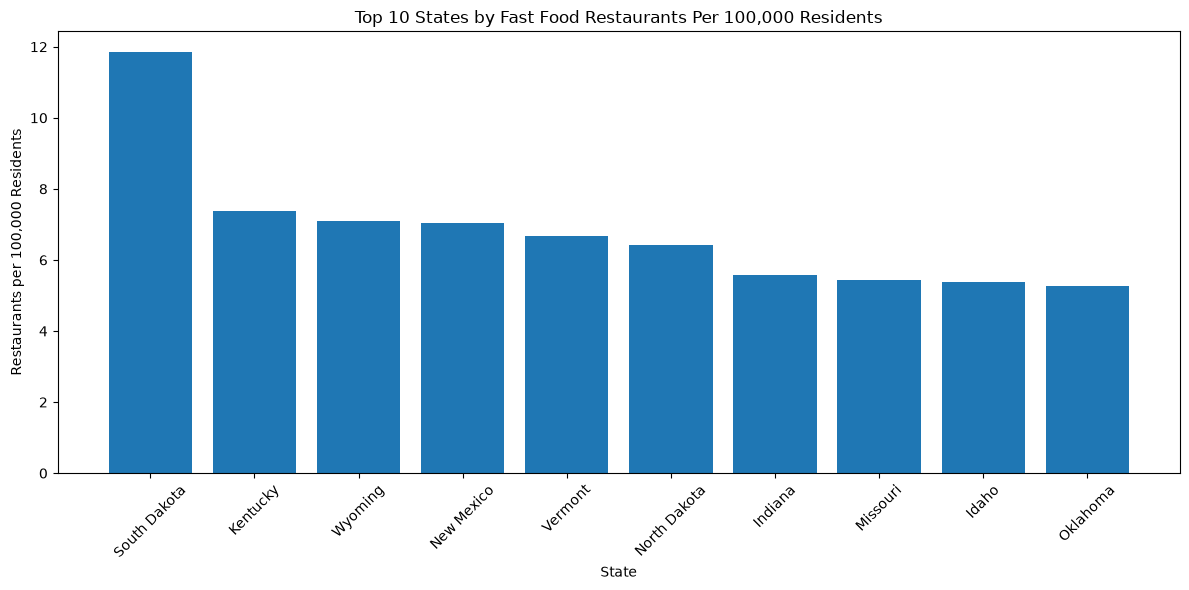

In [12]:
plt.figure(figsize=(12,6))

plt.bar(
    top10["state_name"],
    top10["restaurants_per_100k"]
)

plt.title(
    "Top 10 States by Fast Food Restaurants Per 100,000 Residents"
)

plt.xlabel("State")
plt.ylabel("Restaurants per 100,000 Residents")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "/Users/aakashreddy/Desktop/fast-food-restaurant-analysis/charts/question7_top10.png",
    dpi=300
)

plt.show()

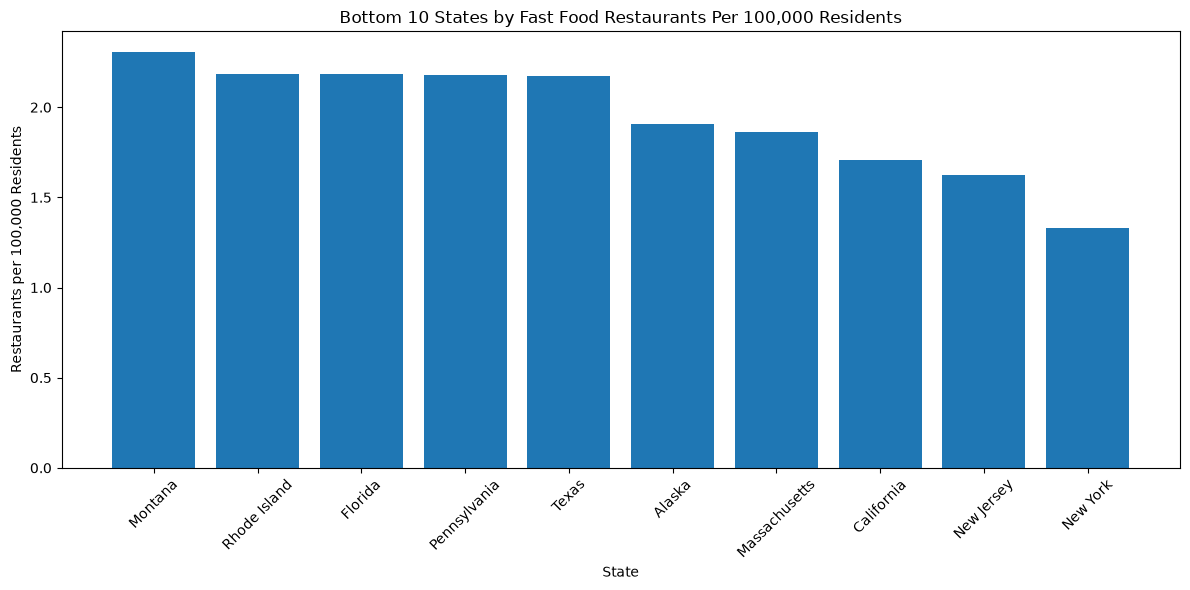

In [13]:
plt.figure(figsize=(12,6))

plt.bar(
    bottom10["state_name"],
    bottom10["restaurants_per_100k"]
)

plt.title(
    "Bottom 10 States by Fast Food Restaurants Per 100,000 Residents"
)

plt.xlabel("State")
plt.ylabel("Restaurants per 100,000 Residents")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "/Users/aakashreddy/Desktop/fast-food-restaurant-analysis/charts/question7_bottom10.png",
    dpi=300
)

plt.show()